# Week 3 - RNN experiments

This notebook stays close to the original course style, but it now includes a wider set of RNN, GRU, and LSTM experiments, a clear training-history collection step, and an explicit inference-efficiency section.


In [46]:
from pathlib import Path
from dataclasses import dataclass
from datetime import datetime
from time import perf_counter
import os
import tempfile

import mlflow
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from mlflow.tracking import MlflowClient

from mads_datasets import DatasetFactoryProvider, DatasetType
from mltrainer import Trainer, TrainerSettings, ReportTypes, rnn_models
from mltrainer.metrics import Accuracy
from mltrainer.preprocessors import PaddedPreprocessor
from torch import Tensor, optim

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

preprocessor = PaddedPreprocessor()
gesturesdatasetfactory = DatasetFactoryProvider.create_factory(DatasetType.GESTURES)
streamers = gesturesdatasetfactory.create_datastreamer(batchsize=32, preprocessor=preprocessor)
train = streamers["train"]
valid = streamers["valid"]

trainstreamer = train.stream()
validstreamer = valid.stream()
x, y = next(iter(trainstreamer))
x.shape, y.shape


2026-04-14 22:34:43.313 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at C:\Users\TEST\.cache\mads_datasets\gestures
100%|██████████| 651/651 [00:00<00:00, 1997.88it/s]


(torch.Size([32, 32, 3]), torch.Size([32]))

## 1. Iterators

The time dimension changes from batch to batch because each gesture has its own length. The preprocessor pads each batch to the longest sequence inside that batch, so one batch might be `(32, 27, 3)` and another might be `(32, 30, 3)`.


In [47]:
len(train), len(valid)


(81, 20)

In [48]:
x.shape, y


(torch.Size([32, 32, 3]),
 tensor([18,  5,  3, 15,  0, 14,  0, 18, 14, 18,  4, 18,  4, 19, 13, 11,  2, 13,
          0,  0,  8,  0,  6, 19, 13,  4,  7, 11, 18,  8,  3, 18]))

## 2. Baseline model

This is a 20-class classification problem, so the output should be `(batch_size, 20)` and cross entropy loss is the correct loss function.


In [49]:
accuracy = Accuracy()
model = rnn_models.BaseRNN(
    input_size=3,
    hidden_size=64,
    num_layers=1,
    horizon=20,
)


In [50]:
yhat = model(x)
yhat.shape


torch.Size([32, 20])

In [51]:
accuracy(y, yhat)


tensor(0.1562)

In [52]:
yhat.shape, y.shape


(torch.Size([32, 20]), torch.Size([32]))

In [53]:
yhat[0]


tensor([ 0.1737, -0.0577, -0.1417, -0.2354,  0.0472,  0.0723,  0.0643,  0.0523,
        -0.0619,  0.0640, -0.0907,  0.1100,  0.0739, -0.0550, -0.0222,  0.0036,
        -0.0015,  0.1483, -0.1294, -0.1719], grad_fn=<SelectBackward0>)

In [54]:
yhat = model(x)
loss_fn = torch.nn.CrossEntropyLoss()
loss = loss_fn(yhat, y)
loss


tensor(3.0143, grad_fn=<NllLossBackward0>)

## 3. Custom recurrent models

I use one small config dataclass and direct model classes for a plain RNN, a GRU, and an LSTM. Each one takes the last hidden state and maps it to the 20 gesture classes.


In [55]:
@dataclass
class ModelConfig:
    input_size: int
    hidden_size: int
    num_layers: int
    output_size: int
    dropout: float = 0.0


class RNNmodel(nn.Module):
    def __init__(self, config) -> None:
        super().__init__()
        self.rnn = nn.RNN(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            dropout=config.dropout,
            batch_first=True,
            num_layers=config.num_layers,
        )
        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.rnn(x)
        last_step = x[:, -1, :]
        yhat = self.linear(last_step)
        return yhat


class GRUmodel(nn.Module):
    def __init__(self, config) -> None:
        super().__init__()
        self.rnn = nn.GRU(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            dropout=config.dropout,
            batch_first=True,
            num_layers=config.num_layers,
        )
        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.rnn(x)
        last_step = x[:, -1, :]
        yhat = self.linear(last_step)
        return yhat


class LSTMmodel(nn.Module):
    def __init__(self, config) -> None:
        super().__init__()
        self.rnn = nn.LSTM(
            input_size=config.input_size,
            hidden_size=config.hidden_size,
            dropout=config.dropout,
            batch_first=True,
            num_layers=config.num_layers,
        )
        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x: Tensor) -> Tensor:
        x, _ = self.rnn(x)
        last_step = x[:, -1, :]
        yhat = self.linear(last_step)
        return yhat


## 4. MLflow setup

The next cell is optional for the notebook itself. It is only useful if I want MLflow logging and want to read the metric history back into pandas tables. If I do not care about MLflow, I could remove `ReportTypes.MLFLOW` and skip the MLflow client helper code.


In [56]:
MLFLOW_DB_PATH = Path("mlflow_overnight.db").resolve()
MLFLOW_URI = f"sqlite:///{MLFLOW_DB_PATH.as_posix()}"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("gestures-overnight")
client = MlflowClient()

modeldir = Path("gestures").resolve()
if not modeldir.exists():
    modeldir.mkdir(parents=True)


## 5. Training and analysis helpers

`Trainer` in the installed `mltrainer` version does not expose `trainer.reporter.reportdf`, so the notebook collects metric history from MLflow instead. This also avoids the old `device=` argument, which is no longer accepted by `Trainer`.


In [57]:
def collect_run_history(run_id: str) -> pd.DataFrame:
    train_loss_history = client.get_metric_history(run_id, "Loss/train")
    valid_loss_history = client.get_metric_history(run_id, "Loss/test")
    valid_accuracy_history = client.get_metric_history(run_id, "metric/Accuracy")

    train_loss_df = pd.DataFrame(
        [{"epoch": item.step, "train_loss": item.value} for item in train_loss_history]
    )
    valid_loss_df = pd.DataFrame(
        [{"epoch": item.step, "valid_loss": item.value} for item in valid_loss_history]
    )
    valid_accuracy_df = pd.DataFrame(
        [{"epoch": item.step, "valid_accuracy": item.value} for item in valid_accuracy_history]
    )

    history = train_loss_df.merge(valid_loss_df, on="epoch", how="outer")
    history = history.merge(valid_accuracy_df, on="epoch", how="outer")
    return history.sort_values("epoch").reset_index(drop=True)


def parameter_count(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters())


def model_size_kb(model: nn.Module) -> float:
    fd, filename = tempfile.mkstemp(suffix=".pt")
    os.close(fd)
    try:
        torch.save(model.state_dict(), filename)
        size = Path(filename).stat().st_size / 1024
    finally:
        if Path(filename).exists():
            Path(filename).unlink()
    return size


def inference_time_ms(model: nn.Module, sample: Tensor, repeats: int = 50) -> float:
    model.eval()
    with torch.no_grad():
        for _ in range(10):
            _ = model(sample)
        start = perf_counter()
        for _ in range(repeats):
            _ = model(sample)
        end = perf_counter()
    return ((end - start) / repeats) * 1000


def train_experiment(experiment: dict) -> tuple[dict, pd.DataFrame, nn.Module]:
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    settings = TrainerSettings(
        epochs=experiment["epochs"],
        metrics=[accuracy],
        logdir=Path("gestures"),
        train_steps=len(train),
        valid_steps=len(valid),
        reporttypes=[ReportTypes.TOML, ReportTypes.TENSORBOARD, ReportTypes.MLFLOW],
        optimizer_kwargs={"lr": experiment["learning_rate"], "weight_decay": 1e-5},
        scheduler_kwargs={"factor": 0.5, "patience": 5},
        earlystop_kwargs={
            "save": False,
            "verbose": True,
            "patience": 5,
            "delta": 0.0,
        },
    )

    model = experiment["model_class"](experiment["config"])

    with mlflow.start_run() as run:
        mlflow.set_tag("model", experiment["model_tag"])
        mlflow.set_tag("dev", "portfolio")
        mlflow.set_tag("model_family", experiment["model_family"])

        trainer = Trainer(
            model=model,
            settings=settings,
            loss_fn=loss_fn,
            optimizer=optim.Adam,
            traindataloader=train.stream(),
            validdataloader=valid.stream(),
            scheduler=optim.lr_scheduler.ReduceLROnPlateau,
            device=device,
        )
        trainer.loop()

        history = collect_run_history(run.info.run_id)
        best_row = history.sort_values("valid_accuracy", ascending=False).iloc[0]
        final_row = history.iloc[-1]

        result = {
            "model_tag": experiment["model_tag"],
            "model_family": experiment["model_family"],
            "hidden_size": experiment["config"].hidden_size,
            "num_layers": experiment["config"].num_layers,
            "dropout": experiment["config"].dropout,
            "learning_rate": experiment["learning_rate"],
            "epochs": experiment["epochs"],
            "best_epoch": int(best_row["epoch"]),
            "best_valid_accuracy": float(best_row["valid_accuracy"]),
            "best_valid_loss": float(best_row["valid_loss"]),
            "final_valid_accuracy": float(final_row["valid_accuracy"]),
            "final_valid_loss": float(final_row["valid_loss"]),
            "param_count": parameter_count(model),
            "model_size_kb": model_size_kb(model),
            "inference_ms_per_batch": inference_time_ms(model, x),
        }

        if not settings.earlystop_kwargs["save"]:
            tag = datetime.now().strftime("%Y%m%d-%H%M-%S-")
            modelpath = modeldir / f"{tag}{experiment['model_tag']}.pt"
            torch.save(model, modelpath)

    history["model_tag"] = experiment["model_tag"]
    return result, history, model


## 6. Experiment space

This is the wider search space to try. It keeps the important anchor runs for the report, but it also adds more hidden sizes, layer counts, dropout settings, and learning rates.


In [58]:
experiments = []


def add_experiment(model_tag, model_family, model_class, hidden_size, num_layers, dropout, learning_rate, epochs):
    experiments.append(
        {
            "model_tag": model_tag,
            "model_family": model_family,
            "model_class": model_class,
            "config": ModelConfig(
                input_size=3,
                hidden_size=hidden_size,
                num_layers=num_layers,
                output_size=20,
                dropout=dropout,
            ),
            "learning_rate": learning_rate,
            "epochs": epochs,
        }
    )


add_experiment("rnn-64-1layer-lr0.001", "RNN", RNNmodel, 64, 1, 0.0, 0.001, 20)
add_experiment("rnn-128-1layer-lr0.001", "RNN", RNNmodel, 128, 1, 0.0, 0.001, 20)
add_experiment("rnn-128-2layer-drop0.1-lr0.001", "RNN", RNNmodel, 128, 2, 0.1, 0.001, 20)
add_experiment("rnn-128-1layer-lr0.01-instability", "RNN", RNNmodel, 128, 1, 0.0, 0.01, 20)
add_experiment("rnn-256-1layer-lr0.0005", "RNN", RNNmodel, 256, 1, 0.0, 0.0005, 25)

add_experiment("gru-64-1layer-lr0.001", "GRU", GRUmodel, 64, 1, 0.0, 0.001, 20)
add_experiment("gru-128-1layer-lr0.001", "GRU", GRUmodel, 128, 1, 0.0, 0.001, 20)
add_experiment("gru-128-1layer-lr0.0005", "GRU", GRUmodel, 128, 1, 0.0, 0.0005, 25)
add_experiment("gru-128-2layer-drop0.1-lr0.001", "GRU", GRUmodel, 128, 2, 0.1, 0.001, 25)
add_experiment("gru-128-2layer-drop0.2-lr0.0005", "GRU", GRUmodel, 128, 2, 0.2, 0.0005, 30)
add_experiment("gru-256-1layer-lr0.001", "GRU", GRUmodel, 256, 1, 0.0, 0.001, 25)
add_experiment("gru-256-2layer-drop0.2-lr0.0005", "GRU", GRUmodel, 256, 2, 0.2, 0.0005, 25)

add_experiment("lstm-64-1layer-lr0.001", "LSTM", LSTMmodel, 64, 1, 0.0, 0.001, 20)
add_experiment("lstm-128-1layer-lr0.001", "LSTM", LSTMmodel, 128, 1, 0.0, 0.001, 20)
add_experiment("lstm-128-1layer-lr0.0005", "LSTM", LSTMmodel, 128, 1, 0.0, 0.0005, 25)
add_experiment("lstm-128-2layer-drop0.1-lr0.001", "LSTM", LSTMmodel, 128, 2, 0.1, 0.001, 25)
add_experiment("lstm-128-2layer-drop0.2-lr0.0005", "LSTM", LSTMmodel, 128, 2, 0.2, 0.0005, 30)
add_experiment("lstm-256-1layer-lr0.001", "LSTM", LSTMmodel, 256, 1, 0.0, 0.001, 25)
add_experiment("lstm-256-2layer-drop0.2-lr0.0005", "LSTM", LSTMmodel, 256, 2, 0.2, 0.0005, 25)

experiment_space_df = pd.DataFrame(
    [
        {
            "model_tag": experiment["model_tag"],
            "model_family": experiment["model_family"],
            "hidden_size": experiment["config"].hidden_size,
            "num_layers": experiment["config"].num_layers,
            "dropout": experiment["config"].dropout,
            "learning_rate": experiment["learning_rate"],
            "epochs": experiment["epochs"],
        }
        for experiment in experiments
    ]
)
experiment_space_df


,model_tag,model_family,hidden_size,num_layers,dropout,learning_rate,epochs
0,rnn-64-1layer-lr0.001,RNN,64,1,0.0,0.0010,20
1,rnn-128-1layer-lr0.001,RNN,128,1,0.0,0.0010,20
2,rnn-128-2layer-drop0.1-lr0.001,RNN,128,2,0.1,0.0010,20
3,rnn-128-1layer-lr0.01-instability,RNN,128,1,0.0,0.0100,20
4,rnn-256-1layer-lr0.0005,RNN,256,1,0.0,0.0005,25
5,gru-64-1layer-lr0.001,GRU,64,1,0.0,0.0010,20
6,gru-128-1layer-lr0.001,GRU,128,1,0.0,0.0010,20
7,gru-128-1layer-lr0.0005,GRU,128,1,0.0,0.0005,25
8,gru-128-2layer-drop0.1-lr0.001,GRU,128,2,0.1,0.0010,25
9,gru-128-2layer-drop0.2-lr0.0005,GRU,128,2,0.2,0.0005,30


In [59]:
experiment_space_summary_df = experiment_space_df.groupby("model_family").agg(
    num_experiments=("model_tag", "size"),
    hidden_sizes=("hidden_size", lambda values: sorted(set(values))),
    layers=("num_layers", lambda values: sorted(set(values))),
    dropouts=("dropout", lambda values: sorted(set(values))),
    learning_rates=("learning_rate", lambda values: sorted(set(values))),
)
experiment_space_summary_df


,num_experiments,hidden_sizes,layers,dropouts,learning_rates
model_family,,,,,
GRU,7,"[64, 128, 256]","[1, 2]","[0.0, 0.1, 0.2]","[0.0005, 0.001]"
LSTM,7,"[64, 128, 256]","[1, 2]","[0.0, 0.1, 0.2]","[0.0005, 0.001]"
RNN,5,"[64, 128, 256]","[1, 2]","[0.0, 0.1]","[0.0005, 0.001, 0.01]"


## 7. Run experiments

The cell below uses the full search space. If I only want a smaller smoke test first, I can replace `run_experiments = experiments` with something like `run_experiments = experiments[:4]`.


In [60]:
results = []
history_frames = []
trained_models = {}

run_experiments = experiments

for experiment in run_experiments:
    result, history, trained_model = train_experiment(experiment)
    results.append(result)
    history_frames.append(history)
    trained_models[experiment["model_tag"]] = trained_model
    print(
        f"{result['model_tag']}: best_valid_accuracy={result['best_valid_accuracy']:.4f}, "
        f"final_valid_accuracy={result['final_valid_accuracy']:.4f}, "
        f"inference_ms_per_batch={result['inference_ms_per_batch']:.3f}"
    )


2026-04-14 22:34:46.843 | INFO     | mltrainer.trainer:dir_add_timestamp:29 - Logging to gestures\20260414-223446
2026-04-14 22:34:46.844 | INFO     | mltrainer.trainer:__init__:65 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|██████████| 81/81 [00:00<00:00, 171.92it/s]
2026-04-14 22:34:47.443 | INFO     | mltrainer.trainer:report:171 - Epoch 0 train 2.8130 test 2.6631 metric ['0.1250']
100%|██████████| 81/81 [00:00<00:00, 161.81it/s]
2026-04-14 22:34:48.069 | INFO     | mltrainer.trainer:report:171 - Epoch 1 train 2.4833 test 2.4434 metric ['0.1141']
100%|██████████| 81/81 [00:00<00:00, 184.71it/s]
2026-04-14 22:34:48.650 | INFO     | mltrainer.trainer:report:171 - Epoch 2 train 2.4431 test 2.4319 metric ['0.1250']
100%|██████████| 81/81 [00:00<00:00, 169.43it/s]
2026-04-14 22:34:49.254 | INFO     | mltrainer.trainer:report:171 - Epoch 3 train 2.3852 test 2.4210 metric ['0.1344']
100%|██████████| 81/81 [00:00<00:00, 184.26it/s]
2026-04-14 22:34:

rnn-64-1layer-lr0.001: best_valid_accuracy=0.1453, final_valid_accuracy=0.1297, inference_ms_per_batch=1.153


100%|██████████| 81/81 [00:00<00:00, 160.52it/s]
2026-04-14 22:34:53.024 | INFO     | mltrainer.trainer:report:171 - Epoch 0 train 2.7045 test 2.4851 metric ['0.1141']
100%|██████████| 81/81 [00:00<00:00, 158.30it/s]
2026-04-14 22:34:53.680 | INFO     | mltrainer.trainer:report:171 - Epoch 1 train 2.4432 test 2.3583 metric ['0.1609']
100%|██████████| 81/81 [00:00<00:00, 159.10it/s]
2026-04-14 22:34:54.376 | INFO     | mltrainer.trainer:report:171 - Epoch 2 train 2.5370 test 2.4041 metric ['0.1453']
2026-04-14 22:34:54.376 | INFO     | mltrainer.trainer:__call__:214 - best loss: 2.3583, current loss 2.4041.Counter 1/5.
100%|██████████| 81/81 [00:00<00:00, 150.23it/s]
2026-04-14 22:34:55.044 | INFO     | mltrainer.trainer:report:171 - Epoch 3 train 2.5193 test 2.5081 metric ['0.1172']
2026-04-14 22:34:55.045 | INFO     | mltrainer.trainer:__call__:214 - best loss: 2.3583, current loss 2.5081.Counter 2/5.
100%|██████████| 81/81 [00:00<00:00, 159.08it/s]
2026-04-14 22:34:55.693 | INFO     

rnn-128-1layer-lr0.001: best_valid_accuracy=0.1609, final_valid_accuracy=0.1078, inference_ms_per_batch=1.411


100%|██████████| 81/81 [00:01<00:00, 73.80it/s]
2026-04-14 22:34:58.459 | INFO     | mltrainer.trainer:report:171 - Epoch 0 train 2.7071 test 2.5151 metric ['0.1141']
100%|██████████| 81/81 [00:01<00:00, 78.10it/s]
2026-04-14 22:34:59.653 | INFO     | mltrainer.trainer:report:171 - Epoch 1 train 2.5557 test 2.4776 metric ['0.1156']
100%|██████████| 81/81 [00:01<00:00, 76.86it/s]
2026-04-14 22:35:00.867 | INFO     | mltrainer.trainer:report:171 - Epoch 2 train 2.4812 test 2.4204 metric ['0.1312']
100%|██████████| 81/81 [00:01<00:00, 74.92it/s]
2026-04-14 22:35:02.128 | INFO     | mltrainer.trainer:report:171 - Epoch 3 train 2.3954 test 2.3538 metric ['0.1672']
100%|██████████| 81/81 [00:01<00:00, 66.79it/s]
2026-04-14 22:35:03.527 | INFO     | mltrainer.trainer:report:171 - Epoch 4 train 2.3832 test 2.3069 metric ['0.1719']
100%|██████████| 81/81 [00:01<00:00, 70.36it/s]
2026-04-14 22:35:04.869 | INFO     | mltrainer.trainer:report:171 - Epoch 5 train 2.4145 test 2.3472 metric ['0.1281'

...

lstm-128-2layer-drop0.2-lr0.0005: best_valid_accuracy=0.9906, final_valid_accuracy=0.9828, inference_ms_per_batch=2.868


100%|██████████| 81/81 [00:01<00:00, 77.11it/s]
2026-04-14 22:44:39.110 | INFO     | mltrainer.trainer:report:171 - Epoch 0 train 2.6244 test 2.2352 metric ['0.1797']
100%|██████████| 81/81 [00:01<00:00, 79.21it/s]
2026-04-14 22:44:40.293 | INFO     | mltrainer.trainer:report:171 - Epoch 1 train 2.1824 test 1.9660 metric ['0.2781']
100%|██████████| 81/81 [00:01<00:00, 61.36it/s]
2026-04-14 22:44:41.769 | INFO     | mltrainer.trainer:report:171 - Epoch 2 train 1.9188 test 1.6645 metric ['0.3922']
100%|██████████| 81/81 [00:01<00:00, 65.85it/s]
2026-04-14 22:44:43.171 | INFO     | mltrainer.trainer:report:171 - Epoch 3 train 1.4509 test 1.2311 metric ['0.5266']
100%|██████████| 81/81 [00:01<00:00, 73.94it/s]
2026-04-14 22:44:44.406 | INFO     | mltrainer.trainer:report:171 - Epoch 4 train 1.0351 test 1.0121 metric ['0.5906']
100%|██████████| 81/81 [00:01<00:00, 75.72it/s]
2026-04-14 22:44:45.640 | INFO     | mltrainer.trainer:report:171 - Epoch 5 train 0.8558 test 0.7753 metric ['0.7375'

lstm-256-1layer-lr0.001: best_valid_accuracy=0.9953, final_valid_accuracy=0.9953, inference_ms_per_batch=2.917


100%|██████████| 81/81 [00:04<00:00, 19.14it/s]
2026-04-14 22:45:13.919 | INFO     | mltrainer.trainer:report:171 - Epoch 0 train 2.6650 test 2.3012 metric ['0.1922']
100%|██████████| 81/81 [00:03<00:00, 20.29it/s]
2026-04-14 22:45:18.174 | INFO     | mltrainer.trainer:report:171 - Epoch 1 train 2.1621 test 2.1798 metric ['0.2297']
100%|██████████| 81/81 [00:03<00:00, 25.77it/s]
2026-04-14 22:45:21.563 | INFO     | mltrainer.trainer:report:171 - Epoch 2 train 1.9611 test 1.7517 metric ['0.3781']
100%|██████████| 81/81 [00:06<00:00, 12.15it/s]
2026-04-14 22:45:28.585 | INFO     | mltrainer.trainer:report:171 - Epoch 3 train 1.4743 test 1.3039 metric ['0.4469']
100%|██████████| 81/81 [00:05<00:00, 14.90it/s]
2026-04-14 22:45:34.387 | INFO     | mltrainer.trainer:report:171 - Epoch 4 train 1.2223 test 1.1666 metric ['0.5078']
100%|██████████| 81/81 [00:07<00:00, 11.10it/s]
2026-04-14 22:45:41.958 | INFO     | mltrainer.trainer:report:171 - Epoch 5 train 0.9927 test 0.9431 metric ['0.5781'

lstm-256-2layer-drop0.2-lr0.0005: best_valid_accuracy=0.9922, final_valid_accuracy=0.9875, inference_ms_per_batch=7.244


In [61]:
results_df = pd.DataFrame(results).sort_values("best_valid_accuracy", ascending=False)
history_df = pd.concat(history_frames, ignore_index=True)

results_df.to_csv("results.csv", index=False)
history_df.to_csv("history.csv", index=False)

results_df


,model_tag,model_family,hidden_size,num_layers,dropout,learning_rate,epochs,best_epoch,best_valid_accuracy,best_valid_loss,final_valid_accuracy,final_valid_loss,param_count,model_size_kb,inference_ms_per_batch
17,lstm-256-1layer-lr0.001,LSTM,256,1,0.0,0.0010,25,24,0.995313,0.034410,0.995313,0.034410,272404,1067.067383,2.916718
11,gru-256-2layer-drop0.2-lr0.0005,GRU,256,2,0.2,0.0005,25,20,0.995313,0.013897,0.992188,0.032839,600340,2349.129883,13.849000
9,gru-128-2layer-drop0.2-lr0.0005,GRU,128,2,0.2,0.0005,30,28,0.993750,0.031983,0.993750,0.031983,152724,600.567383,6.699004
8,gru-128-2layer-drop0.1-lr0.001,GRU,128,2,0.1,0.0010,25,17,0.993750,0.026269,0.985937,0.056415,152724,600.567383,6.185768
18,lstm-256-2layer-drop0.2-lr0.0005,LSTM,256,2,0.2,0.0005,25,18,0.992188,0.055141,0.987500,0.068175,798740,3124.129883,7.243780
6,gru-128-1layer-lr0.001,GRU,128,1,0.0,0.0010,20,18,0.992188,0.035298,0.989062,0.038124,53652,212.567383,6.272744
15,lstm-128-2layer-drop0.1-lr0.001,LSTM,128,2,0.1,0.0010,25,21,0.992188,0.031612,0.987500,0.075342,202772,796.129883,2.791514
10,gru-256-1layer-lr0.001,GRU,256,1,0.0,0.0010,25,13,0.992188,0.035075,0.979688,0.081212,205588,806.067383,4.636912
16,lstm-128-2layer-drop0.2-lr0.0005,LSTM,128,2,0.2,0.0005,30,26,0.990625,0.051486,0.982813,0.086868,202772,796.129883,2.868334
7,gru-128-1layer-lr0.0005,GRU,128,1,0.0,0.0005,25,24,0.984375,0.080885,0.984375,0.080885,53652,212.567383,2.960460


## 8. Training behaviour

These plots are useful for the report because they show that the plain RNN, especially with the higher learning rate, is less stable than the gated recurrent models.


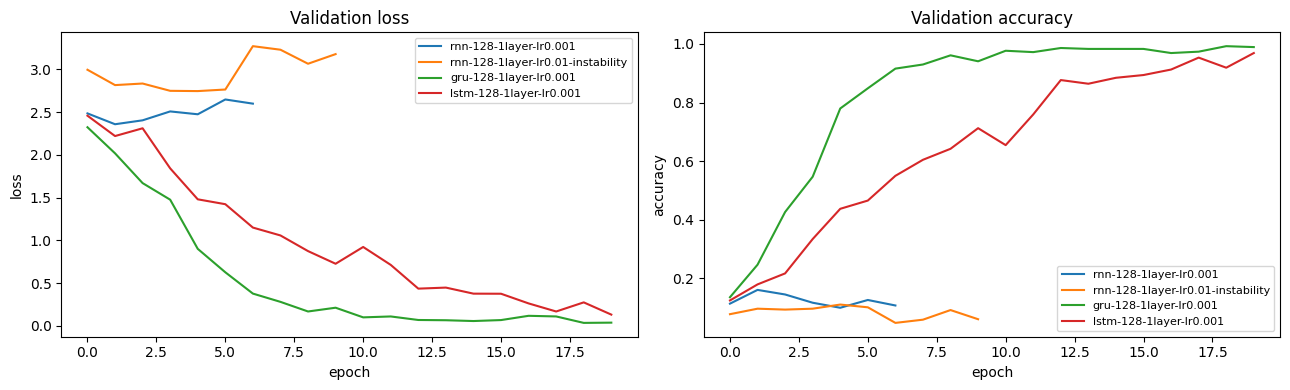

In [62]:
plot_tags = [
    "rnn-128-1layer-lr0.001",
    "rnn-128-1layer-lr0.01-instability",
    "gru-128-1layer-lr0.001",
    "lstm-128-1layer-lr0.001",
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for model_tag in plot_tags:
    subset = history_df[history_df["model_tag"] == model_tag]
    axes[0].plot(subset["epoch"], subset["valid_loss"], label=model_tag)
    axes[1].plot(subset["epoch"], subset["valid_accuracy"], label=model_tag)

axes[0].set_title("Validation loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("loss")
axes[1].set_title("Validation accuracy")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


In [63]:
instability_subset = history_df[history_df["model_tag"] == "rnn-128-1layer-lr0.01-instability"]
instability_subset[["epoch", "train_loss", "valid_loss", "valid_accuracy"]]


,epoch,train_loss,valid_loss,valid_accuracy
26,0,2.934626,2.995404,0.078125
27,1,2.911631,2.815996,0.096875
28,2,2.801078,2.834416,0.093750
29,3,2.810960,2.749029,0.096875
30,4,2.763164,2.745957,0.110937
31,5,2.969287,2.764327,0.101562
32,6,3.254256,3.271245,0.048437
33,7,3.197865,3.229721,0.059375
34,8,3.157654,3.065747,0.092188
35,9,3.173257,3.178316,0.060938


## 9. Inference efficiency

This is the part that compares parameter count, saved weight size, and average CPU inference time per batch. It is now explicit in the notebook instead of being hidden in earlier drafts.


In [ ]:
efficiency_df = results_df[
    [
        "model_tag",
        "model_family",
        "best_valid_accuracy",
        "param_count",
        "model_size_kb",
        "inference_ms_per_batch",
    ]
].sort_values("inference_ms_per_batch")
efficiency_df


,model_tag,model_family,best_valid_accuracy,param_count,model_size_kb,inference_ms_per_batch
12,lstm-64-1layer-lr0.001,LSTM,0.889063,18964,77.067383,0.857606
0,rnn-64-1layer-lr0.001,RNN,0.145313,5716,25.317383,1.152622
14,lstm-128-1layer-lr0.0005,LSTM,0.957812,70676,279.067383,1.163078
1,rnn-128-1layer-lr0.001,RNN,0.160938,19604,79.567383,1.410582
13,lstm-128-1layer-lr0.001,LSTM,0.968750,70676,279.067383,1.411184
3,rnn-128-1layer-lr0.01-instability,RNN,0.110937,19604,79.567383,1.436516
4,rnn-256-1layer-lr0.0005,RNN,0.171875,71956,284.067383,1.924076
5,gru-64-1layer-lr0.001,GRU,0.965625,14548,59.817383,2.223562
2,rnn-128-2layer-drop0.1-lr0.001,RNN,0.171875,52628,209.567383,2.754232
15,lstm-128-2layer-drop0.1-lr0.001,LSTM,0.992188,202772,796.129883,2.791514


: 

## 10. Conv1D follow-up assignment

The assignment also asks for a Conv1D experiment. I keep this as a separate follow-up section so the executed RNN, GRU, and LSTM results above stay reproducible. A Conv1D model expects channels first, so the input is transposed from `(batch, time, features)` to `(batch, features, time)` before the convolution blocks.


In [ ]:
class Conv1DGestureModel(nn.Module):
    def __init__(self, config) -> None:
        super().__init__()
        layers = []
        in_channels = config.input_size

        for _ in range(config.num_layers):
            layers.extend(
                [
                    nn.Conv1d(
                        in_channels=in_channels,
                        out_channels=config.hidden_size,
                        kernel_size=3,
                        padding=1,
                    ),
                    nn.BatchNorm1d(config.hidden_size),
                    nn.ReLU(),
                ]
            )
            if config.dropout > 0:
                layers.append(nn.Dropout(config.dropout))
            in_channels = config.hidden_size

        self.feature_extractor = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x: Tensor) -> Tensor:
        x = x.transpose(1, 2)
        features = self.feature_extractor(x)
        pooled = self.pool(features).squeeze(-1)
        return self.linear(pooled)


In [ ]:
conv1d_config = ModelConfig(
    input_size=3,
    hidden_size=64,
    num_layers=2,
    output_size=20,
    dropout=0.1,
)
conv1d_model = Conv1DGestureModel(conv1d_config)
conv1d_yhat = conv1d_model(x)
conv1d_yhat.shape


In [ ]:
conv1d_followup_experiments = [
    {
        "model_tag": "conv1d-64-2layer-drop0.1-lr0.001",
        "model_family": "Conv1D",
        "model_class": Conv1DGestureModel,
        "config": ModelConfig(
            input_size=3,
            hidden_size=64,
            num_layers=2,
            output_size=20,
            dropout=0.1,
        ),
        "learning_rate": 0.001,
        "epochs": 20,
    },
    {
        "model_tag": "conv1d-128-3layer-drop0.2-lr0.0005",
        "model_family": "Conv1D",
        "model_class": Conv1DGestureModel,
        "config": ModelConfig(
            input_size=3,
            hidden_size=128,
            num_layers=3,
            output_size=20,
            dropout=0.2,
        ),
        "learning_rate": 0.0005,
        "epochs": 25,
    },
]

pd.DataFrame(
    [
        {
            "model_tag": experiment["model_tag"],
            "model_family": experiment["model_family"],
            "hidden_size": experiment["config"].hidden_size,
            "num_layers": experiment["config"].num_layers,
            "dropout": experiment["config"].dropout,
            "learning_rate": experiment["learning_rate"],
            "epochs": experiment["epochs"],
        }
        for experiment in conv1d_followup_experiments
    ]
)


To run the Conv1D follow-up without repeating the full recurrent sweep, run the next cell after the helper functions are loaded. It is commented out by default because it performs training and should only be run when runtime is acceptable.


In [ ]:
# conv1d_results = []
# conv1d_history_frames = []
# conv1d_trained_models = {}
#
# for experiment in conv1d_followup_experiments:
#     result, history, trained_model = train_experiment(experiment)
#     conv1d_results.append(result)
#     conv1d_history_frames.append(history)
#     conv1d_trained_models[experiment["model_tag"]] = trained_model
#     print(
#         f"{result['model_tag']}: best_valid_accuracy={result['best_valid_accuracy']:.4f}, "
#         f"final_valid_accuracy={result['final_valid_accuracy']:.4f}, "
#         f"inference_ms_per_batch={result['inference_ms_per_batch']:.3f}"
#     )
#
# conv1d_results_df = pd.DataFrame(conv1d_results).sort_values("best_valid_accuracy", ascending=False)
# conv1d_history_df = pd.concat(conv1d_history_frames, ignore_index=True)
# conv1d_results_df.to_csv("conv1d_results.csv", index=False)
# conv1d_history_df.to_csv("conv1d_history.csv", index=False)
# conv1d_results_df


## 11. Overnight recurrent sweep

This optional section combines broader RNN, GRU, LSTM, and Conv1D candidates for a long unattended run. It writes separate `results_overnight.csv` and `history_overnight.csv` files so the existing measured results stay untouched.


In [ ]:
RUN_OVERNIGHT_RNN = False
OVERNIGHT_RESULTS_PATH = Path("results_overnight.csv")
OVERNIGHT_HISTORY_PATH = Path("history_overnight.csv")

def make_experiment(model_tag, model_family, model_class, hidden_size, num_layers, dropout, learning_rate, epochs):
    return {
        "model_tag": model_tag,
        "model_family": model_family,
        "model_class": model_class,
        "config": ModelConfig(
            input_size=3,
            hidden_size=hidden_size,
            num_layers=num_layers,
            output_size=20,
            dropout=dropout,
        ),
        "learning_rate": learning_rate,
        "epochs": epochs,
    }

overnight_model_grid = {
    "RNN": (RNNmodel, [64, 128, 256], [1, 2], [0.0, 0.1], [5e-4, 1e-3, 3e-3], 30),
    "GRU": (GRUmodel, [64, 128, 256, 384], [1, 2, 3], [0.0, 0.1, 0.2, 0.35], [3e-4, 5e-4, 1e-3, 2e-3], 40),
    "LSTM": (LSTMmodel, [64, 128, 256, 384], [1, 2, 3], [0.0, 0.1, 0.2, 0.35], [3e-4, 5e-4, 1e-3, 2e-3], 40),
    "Conv1D": (Conv1DGestureModel, [64, 128, 256], [2, 3, 4], [0.0, 0.1, 0.2, 0.35], [3e-4, 5e-4, 1e-3, 2e-3], 35),
}

# Long-run budget adjustment: keep the full grid visible, but use the
# two central learning rates for the larger LSTM and Conv1D families.
reduced_long_family_learning_rates = [5e-4, 1e-3]
overnight_model_grid["LSTM"] = (
    LSTMmodel,
    [64, 128, 256, 384],
    [1, 2, 3],
    [0.0, 0.1, 0.2, 0.35],
    reduced_long_family_learning_rates,
    40,
)
overnight_model_grid["Conv1D"] = (
    Conv1DGestureModel,
    [64, 128, 256],
    [2, 3, 4],
    [0.0, 0.1, 0.2, 0.35],
    reduced_long_family_learning_rates,
    35,
)

# Keep the main overnight sweep focused on recurrent models.
# Conv1D can be evaluated through the follow-up cell above.
overnight_model_grid.pop("Conv1D", None)

overnight_recurrent_experiments = []
for family, (model_class, hidden_sizes, layer_counts, dropouts, learning_rates, epochs) in overnight_model_grid.items():
    for hidden_size in hidden_sizes:
        for num_layers in layer_counts:
            for dropout in dropouts:
                if num_layers == 1 and dropout > 0 and family != "Conv1D":
                    continue
                for learning_rate in learning_rates:
                    tag = f"overnight-{family.lower()}-{hidden_size}-{num_layers}layer-drop{dropout}-lr{learning_rate}"
                    overnight_recurrent_experiments.append(
                        make_experiment(tag, family, model_class, hidden_size, num_layers, dropout, learning_rate, epochs)
                    )

print(f"Prepared {len(overnight_recurrent_experiments)} overnight recurrent experiments.")
pd.DataFrame(
    [
        {
            "model_tag": experiment["model_tag"],
            "model_family": experiment["model_family"],
            "hidden_size": experiment["config"].hidden_size,
            "num_layers": experiment["config"].num_layers,
            "dropout": experiment["config"].dropout,
            "learning_rate": experiment["learning_rate"],
            "epochs": experiment["epochs"],
        }
        for experiment in overnight_recurrent_experiments
    ]
).head(25)


In [ ]:
if RUN_OVERNIGHT_RNN:
    completed = pd.DataFrame()
    if OVERNIGHT_RESULTS_PATH.exists():
        completed = pd.read_csv(OVERNIGHT_RESULTS_PATH)
    completed_tags = set(completed["model_tag"]) if not completed.empty else set()

    new_results = []
    new_history_frames = []
    for experiment in overnight_recurrent_experiments:
        if experiment["model_tag"] in completed_tags:
            continue
        result, history, trained_model = train_experiment(experiment)
        new_results.append(result)
        new_history_frames.append(history)

        partial_results = pd.concat([completed, pd.DataFrame(new_results)], ignore_index=True)
        partial_results = partial_results.sort_values("best_valid_accuracy", ascending=False).reset_index(drop=True)
        partial_results.to_csv(OVERNIGHT_RESULTS_PATH, index=False)

        if OVERNIGHT_HISTORY_PATH.exists():
            existing_history = pd.read_csv(OVERNIGHT_HISTORY_PATH)
            partial_history = pd.concat([existing_history, *new_history_frames], ignore_index=True)
        else:
            partial_history = pd.concat(new_history_frames, ignore_index=True)
        partial_history.to_csv(OVERNIGHT_HISTORY_PATH, index=False)

        print(
            f"{result['model_tag']}: best_valid_accuracy={result['best_valid_accuracy']:.4f}, "
            f"final_valid_accuracy={result['final_valid_accuracy']:.4f}"
        )

    overnight_results_df = pd.read_csv(OVERNIGHT_RESULTS_PATH).sort_values("best_valid_accuracy", ascending=False)
    display(overnight_results_df.head(20))
else:
    print("Set RUN_OVERNIGHT_RNN = True to run the long recurrent sweep.")
